In [28]:
import pandas as pd
import numpy as np

# 先讀進模擬資料
# data = pd.read_csv(r"C:\Users\USER\Desktop\碩論\程式碼\embedding_data.csv")

data = pd.read_csv(r"C:\Users\USER\Desktop\碩論\程式碼\B\raw_data.csv")

cols = data.columns[:-1].to_list() 

whole = data.copy()

data = whole.iloc[0:100,:]

data[cols] = (data[cols] - data[cols].mean()) / data[cols].std() # 針對變數標準化，後面做softmax的時候，數值才不會爆掉

validation = whole.iloc[100:200,:]

validation[cols] = (validation[cols] - validation[cols].mean()) / validation[cols].std()

# print(len(whole))
# print(len(data))
# print(len(validation))
print(data)

          X1        X2        X3        X4        X5        X6        X7  \
0   0.601388  0.641604 -0.218694 -0.216190  0.753663  0.713873  1.453768   
1  -0.210351 -0.184570  1.526515  1.511484  0.875364  0.883901 -0.622718   
2  -0.465007 -0.467575 -0.551446 -0.548911  0.341316  0.369505 -2.127379   
3  -0.574820 -0.600708 -1.107382 -1.091815  0.414781  0.428755 -1.079752   
4   1.677561  1.692656 -0.307619 -0.307409  0.164036  0.186393 -1.618256   
..       ...       ...       ...       ...       ...       ...       ...   
95 -0.226899 -0.234533  0.507670  0.503081  0.411735  0.464963  3.075197   
96 -0.092375 -0.094933 -1.049166 -1.022169 -1.537256 -1.482861  0.078583   
97 -1.529964 -1.599205 -0.735210 -0.745180 -1.003792 -0.975273  1.624797   
98  0.040845  0.065930  1.425643  1.431883  0.174036  0.197251 -1.031043   
99  0.648254  0.653369 -1.132191 -1.123368 -0.098039 -0.088059 -1.045981   

          X8        X9       X10         Y  
0   1.437179 -0.188246 -0.133355 -0.032517

C:\Users\USER\AppData\Local\Temp\ipykernel_1216\569553184.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[cols] = (data[cols] - data[cols].mean()) / data[cols].std() # 針對變數標準化，後面做softmax的時候，數值才不會爆掉
C:\Users\USER\AppData\Local\Temp\ipykernel_1216\569553184.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  validation[cols] = (validation[cols] - validation[cols].mean()) / validation[cols].std()


In [29]:
X = data[cols]

XTX = X.T @ X

y = data["Y"]

# beta
beta = np.linalg.inv(X.T @ X) @ X.T @ y

print("手算:")
print(beta)
print("---------------------------------------------")

# 用套件驗證
import statsmodels.api as sm

X = data[cols]

model = sm.OLS(
    data["Y"],
    X          # 不加 constant
)

result = model.fit()

print("套件驗證:")
print(result.params)

手算:
0    3.166456
1   -1.680352
2   -0.802338
3    2.572685
4    4.456227
5   -4.498239
6   -1.910845
7    2.042896
8    1.050301
9   -1.180557
dtype: float64
---------------------------------------------
套件驗證:
X1     3.166456
X2    -1.680352
X3    -0.802338
X4     2.572685
X5     4.456227
X6    -4.498239
X7    -1.910845
X8     2.042896
X9     1.050301
X10   -1.180557
dtype: float64


In [30]:
import torch

X = torch.tensor(
    data[cols].values,
    dtype=torch.float32
)

y = torch.tensor(
    data["Y"].values,
    dtype=torch.float32
)

# y_true = y.mean()

# y_true = y_true.reshape(1,1)

N = X.shape[0]
P = X.shape[1]

In [31]:
y

tensor([-0.0325,  2.2801, -2.5065, -3.1635,  0.2463, -1.6361,  2.2569, -2.6867,
         2.3267, -1.1038, -1.8088, -0.6531, -1.9779,  1.3222,  4.3311,  1.4657,
        -0.0643, -1.3804,  2.5628, -3.3507, -3.2574,  4.4095, -2.0474, -0.8430,
        -3.3706,  2.3617, -0.7609,  2.6901,  3.0220, -1.3109,  1.9088,  0.9697,
         0.1738,  2.8349, -1.9788,  4.5091,  0.0093,  1.5501,  0.7298, -2.7048,
         0.9498, -1.2099,  2.5291,  0.1110, -0.0845,  3.2537, -0.9083, -2.5704,
        -1.9389, -1.2970,  0.2484,  0.5209, -2.5079,  0.3862, -1.3979,  0.2782,
         0.9319, -2.8237, -0.9881,  0.5666, -1.5684,  2.2991,  2.0396,  1.0923,
         1.5220, -0.7783, -4.2510, -1.8865,  0.4350, -1.1710,  4.2617, -0.5040,
         3.7632, -0.1485,  0.3401, -0.1539, -1.9206,  2.1587, -0.8386, -4.3915,
        -3.9534, -0.1766, -2.2617, -0.9117,  6.2768, -0.5864, -6.3574,  2.9265,
         0.1202,  3.3456,  1.9597, -1.2430,  4.2756, -0.4757, -3.5197,  0.5051,
        -1.2169, -4.9128,  1.0341, -0.01

In [32]:
X

tensor([[ 6.0139e-01,  6.4160e-01, -2.1869e-01, -2.1619e-01,  7.5366e-01,
          7.1387e-01,  1.4538e+00,  1.4372e+00, -1.8825e-01, -1.3336e-01],
        [-2.1035e-01, -1.8457e-01,  1.5265e+00,  1.5115e+00,  8.7536e-01,
          8.8390e-01, -6.2272e-01, -5.8257e-01,  5.3576e-01,  5.3403e-01],
        [-4.6501e-01, -4.6758e-01, -5.5145e-01, -5.4891e-01,  3.4132e-01,
          3.6951e-01, -2.1274e+00, -2.1442e+00, -1.5778e+00, -1.5921e+00],
        [-5.7482e-01, -6.0071e-01, -1.1074e+00, -1.0918e+00,  4.1478e-01,
          4.2875e-01, -1.0798e+00, -1.1055e+00, -1.2864e+00, -1.3239e+00],
        [ 1.6776e+00,  1.6927e+00, -3.0762e-01, -3.0741e-01,  1.6404e-01,
          1.8639e-01, -1.6183e+00, -1.6320e+00, -4.7742e-01, -5.2509e-01],
        [ 1.7290e-01,  1.8037e-01, -1.2478e+00, -1.2475e+00,  4.7723e-01,
          4.4622e-01, -7.5941e-01, -7.9123e-01, -2.4188e-01, -2.8406e-01],
        [-6.1860e-01, -5.9312e-01,  1.8040e+00,  1.7806e+00,  8.1688e-02,
          3.0284e-02, -1.2357e+0

In [33]:
import torch.nn as nn

embedding_dim = len(data)
dk = 4

wq = torch.randn(
    dk,
    embedding_dim,
    requires_grad=True
)

wk = torch.randn(
    dk,
    embedding_dim,
    requires_grad=True
)

# 先不需要V
# wv = torch.randn(
#     embedding_dim,
#     embedding_dim,
#     requires_grad=True
# )

# proj = nn.Linear(
#     embedding_dim,
#     1
# )

# linear = nn.Linear(
#     P,
#     1
# )

In [34]:
optimizer = torch.optim.Adam(

    [wq,wk], # wv

    # +list(proj.parameters())

    # +list(linear.parameters()),

    lr=0.001

)

In [35]:
import numpy as np
import torch.nn.functional as F

lam = 1

p = X.shape[1]

I = torch.eye(
    p,
    dtype=X.dtype,
    device=X.device
)

loss_history = []

initial_attn = None

epochs = 1000

for epoch in range(epochs):

    E = X

    Q = wq @ E

    K = wk @ E

    scores = K.T @ Q 

    scores = scores / np.sqrt(dk)

    attn = F.softmax(
        scores,
        dim=0
    )

    A = attn @ attn.T + lam * I

    # beta
    beta = torch.linalg.solve(
    X.T @ X + A,
    X.T @ y
    )

    # V = wv @ E

    # delta_E = V @ attn

    # New_E = E + delta_E

    # z = proj(
    # New_E.T
    # )

    # z = z.reshape(1,-1)

    # y_hat = linear(z)

#    mse_loss = F.mse_loss(
#    y_hat,
#    y
#    )

#    lambda_attn=0.1

#    loss = (
#        mse_loss
#        +
#        lambda_attn *
#        torch.mean(attn**2)
#    )

    y_hat = X @ beta

    loss = F.mse_loss(
    y_hat,
    y
    )


    if epoch == 0:
        initial_attn = attn.detach().clone()

        # mean_initial_attn = initial_attn.mean(dim=0)

        # print(E.shape)

        # print(Q.shape)

        # print(K.shape)

        # print(scores.shape)

        # print(attn.shape)

        # print(V.shape)

        # print(delta_E.shape)

        # print(New_E.shape)

        # print(z.shape)

        print(y_hat.shape)
        
        print(y.shape)


    loss_history.append(
        loss.item()
    )

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

# =====================
# 訓練完成後重新 forward
# 取得最後 attention
# =====================

with torch.no_grad():

    E = X

    Q = wq @ E

    K = wk @ E

    scores = K.T @ Q 

    scores = scores / np.sqrt(dk)

    attn = F.softmax(
        scores,
        dim=0
    )

    final_attn = attn.clone()
    
    A = attn @ attn.T + lam * I

    # beta
    beta1 = torch.linalg.solve(
    X.T @ X + A,
    X.T @ y
    )

print("訓練完之後的beta:")
print(beta1)

# =====================
# Average attention matrix across all samples
# =====================

# mean_attn = final_attn.mean(dim=0)



torch.Size([100])
torch.Size([100])
訓練完之後的beta:
tensor([ 0.8239,  0.6661,  0.8280,  0.9301,  0.1697, -0.2055, -0.0588,  0.1875,
        -0.0361, -0.1064])


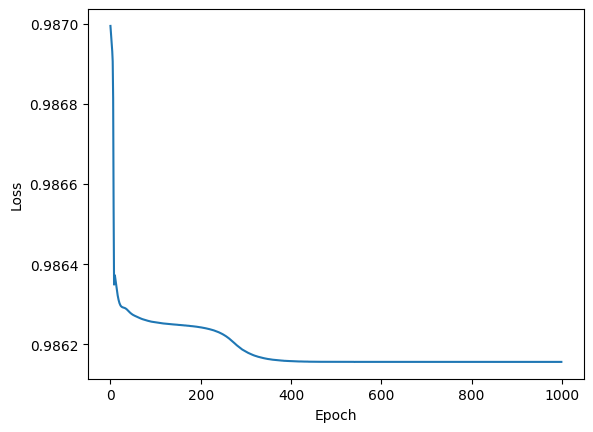

In [36]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

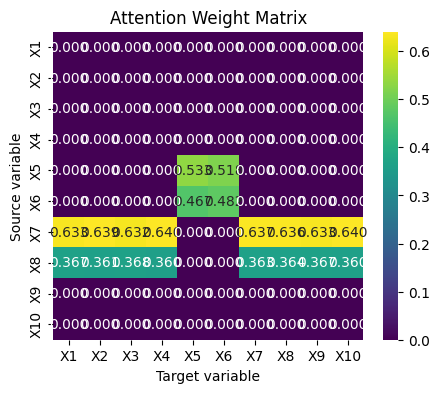

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
# 轉成 numpy
attn_matrix = final_attn.detach().numpy()

# 設定變數名稱
labels = cols

plt.figure(figsize=(5,4))

sns.heatmap(
    attn_matrix,
    annot=True,        # 顯示數值
    fmt=".3f",         # 小數三位
    xticklabels=labels,
    yticklabels=labels,
    cmap="viridis"
)

plt.xlabel("Target variable")
plt.ylabel("Source variable")
plt.title("Attention Weight Matrix")

plt.show()

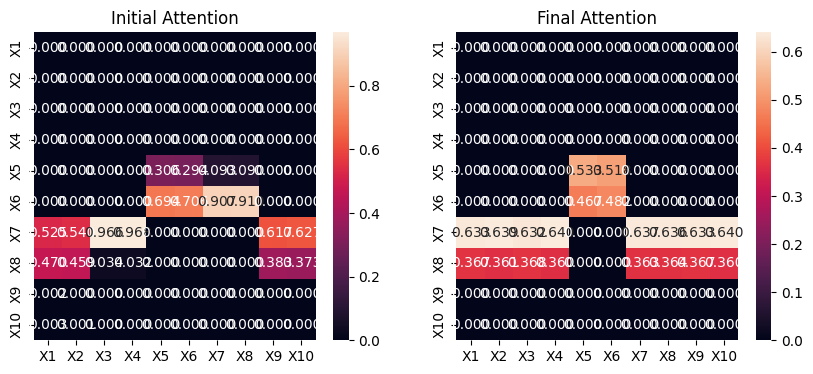

In [38]:
fig, axes = plt.subplots(1,2,figsize=(10,4))

sns.heatmap(
    initial_attn.detach().numpy(),
    annot=True,
    fmt=".3f",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[0]
)

axes[0].set_title("Initial Attention")


sns.heatmap(
    final_attn.detach().numpy(),
    annot=True,
    fmt=".3f",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[1]
)

axes[1].set_title("Final Attention")


plt.show()

In [39]:
beta_ols = result.params.values
beta_attn = beta1.detach().numpy()

In [40]:
print(beta_ols)
print(beta_attn)

[ 3.16645632 -1.68035158 -0.80233806  2.5726851   4.45622736 -4.49823882
 -1.91084482  2.04289604  1.05030067 -1.18055738]
[ 0.82387656  0.666134    0.82800996  0.93005246  0.16974793 -0.20551912
 -0.05878879  0.18747187 -0.0360977  -0.10644528]


In [41]:
X_val = validation[cols].values
y_val = validation["Y"].values

y_pred_ols = X_val @ beta_ols

y_pred_attn = X_val @ beta_attn

In [42]:
from sklearn.metrics import mean_squared_error

mse_ols = mean_squared_error(
    y_val,
    y_pred_ols
)

mse_attn = mean_squared_error(
    y_val,
    y_pred_attn
)

print(f"OLS MSE = {mse_ols:.6f}")
print(f"Attention MSE = {mse_attn:.6f}")

OLS MSE = 1.407545
Attention MSE = 1.316533


In [43]:
rmse_ols = np.sqrt(mse_ols)
rmse_attn = np.sqrt(mse_attn)

print(f"OLS MSE = {rmse_ols:.6f}")
print(f"Attention MSE = {rmse_attn:.6f}")

OLS MSE = 1.186400
Attention MSE = 1.147403


In [44]:
from sklearn.metrics import r2_score

ols_r2 = r2_score(y_val, y_pred_ols)
attn_r2 = r2_score(y_val, y_pred_attn)

print(f"OLS R² = {ols_r2:.6f}")
print(f"Attention R² = {attn_r2:.6f}")

OLS R² = 0.825680
Attention R² = 0.836952


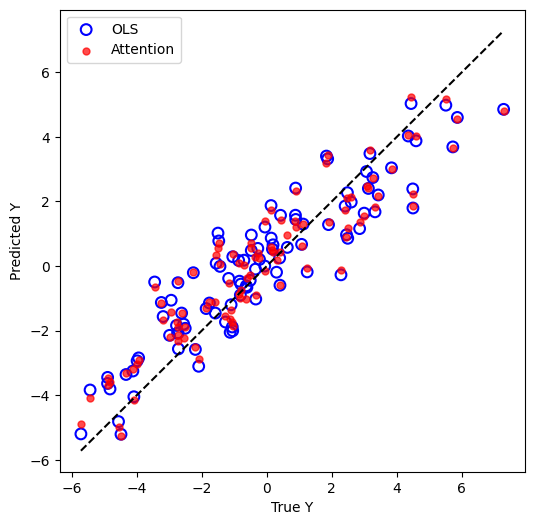

In [45]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_val,
    y_pred_ols,
    facecolors="none",
    edgecolors="blue",
    s=60,
    linewidth=1.5,
    label="OLS"
)

plt.scatter(
    y_val,
    y_pred_attn,
    color="red",
    s=25,
    alpha=0.7,
    label="Attention"
)

low = min(y_val.min(), y_pred_ols.min(), y_pred_attn.min())
high = max(y_val.max(), y_pred_ols.max(), y_pred_attn.max())

plt.plot([low, high], [low, high], "k--")

plt.xlabel("True Y")
plt.ylabel("Predicted Y")
plt.legend()
plt.show()